In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from lifelines import CoxPHFitter, KaplanMeierFitter
from lifelines.utils import concordance_index
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


In [2]:
# Load data
path = "/teamspace/studios/this_studio/WiDS/"

train = pd.read_csv(path + "train.csv")
test  = pd.read_csv(path + "test.csv")
meta  = pd.read_csv(path + "metaData.csv")

print(f"Train: {train.shape}")
print(f"Test:  {test.shape}")


Train: (221, 37)
Test:  (95, 35)


In [5]:
# Define target columns
duration_col = 'time_to_hit_hours'
event_col = 'event'


In [ ]:
# Inspect target variable distributions
print(f'Event rate:     {train[event_col].mean():.2%}')
print(f'Censoring rate: {(train[event_col] == 0).mean():.2%}')
print(f'Duration stats: {train[duration_col].describe()}')


Event rate: 31.22%
Cencoring rate: 68.78%
Duration Stats: count    221.000000
mean      37.567626
std       25.902361
min        0.001220
25%       12.242322
50%       43.109830
75%       63.938706
max       66.994474
Name: time_to_hit_hours, dtype: float64


In [7]:
# EDA — check for missing values
missing = train.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Missing values:")
print(missing if not missing.empty else "None")


Missing values:
Series([], dtype: int64)


In [8]:
# Identify highly skewed numeric features
num_cols = train.select_dtypes(include='number').columns.tolist()
skewness = train[num_cols].skew().sort_values(ascending=False)
print('Top skewed columns:')
print(skewness.head(10))


Top skewed columns:
area_growth_rel_0_5h         11.951708
relative_growth_0_5h         11.951708
dist_std_ci_0_5h             11.589398
area_growth_abs_0_5h         11.231250
projected_advance_m          11.187420
closing_speed_abs_m_per_h    11.152232
closing_speed_m_per_h        10.994165
area_growth_rate_ha_per_h    10.281604
centroid_speed_m_per_h        6.959181
centroid_displacement_m       6.753091
dtype: float64


In [9]:
# Fit Kaplan-Meier estimator to visualize overall survival pattern
kmf = KaplanMeierFitter()
kmf.fit(durations=train[duration_col], event_observed=train[event_col])


<lifelines.KaplanMeierFitter:"KM_estimate", fitted with 221 total observations, 152 right-censored observations>

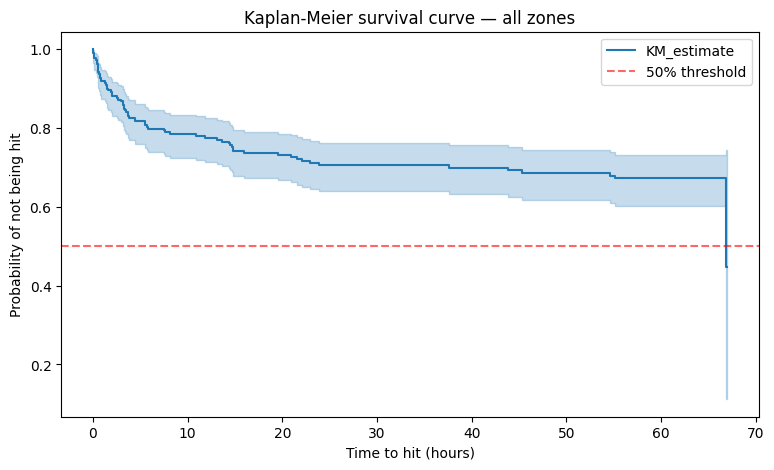

In [10]:

plt.figure(figsize=(9, 5))
kmf.plot_survival_function(ci_show=True)
plt.title('Kaplan-Meier Survival Curve — All Zones')
plt.xlabel('Time to hit (hours)')
plt.ylabel('Survival probability')
plt.axhline(0.5, linestyle='--', alpha=0.6, color='red', label='50% threshold')
plt.legend()
plt.show()


The KM curve shows that at least 75% of zones survive (i.e., are not hit by wildfire) within the first 12 hours after fire detection, and more than 60% survive within the first 24 hours.

In [11]:
def engineer_features(df):
    df = df.copy()

    # Apply log1p transform to right-skewed columns to reduce skewness
    skewed_cols = [
        'area_growth_rel_0_5h', 'relative_growth_0_5h', 'dist_std_ci_0_5h',
        'area_growth_abs_0_5h', 'projected_advance_m', 'closing_speed_abs_m_per_h',
        'closing_speed_m_per_h', 'area_growth_rate_ha_per_h'
    ]
    for col in skewed_cols:
        df[f'log_{col}'] = np.log1p(df[col].clip(lower=0))

    return df


In [12]:
train = engineer_features(train)
test  = engineer_features(test)


In [13]:
print(f"Features after engineering: {train.shape[1]}")


Features after engineering: 45


In [14]:
# Construct feature matrix — exclude ID and target columns
drop_cols = ['event_id', duration_col, event_col]
feature_cols = [
    col for col in train.columns
    if col not in drop_cols and train[col].dtype != 'object'
]

print(f"Number of features: {len(feature_cols)}")
print(feature_cols)


Number of features: 42
['num_perimeters_0_5h', 'dt_first_last_0_5h', 'low_temporal_resolution_0_5h', 'area_first_ha', 'area_growth_abs_0_5h', 'area_growth_rel_0_5h', 'area_growth_rate_ha_per_h', 'log1p_area_first', 'log1p_growth', 'log_area_ratio_0_5h', 'relative_growth_0_5h', 'radial_growth_m', 'radial_growth_rate_m_per_h', 'centroid_displacement_m', 'centroid_speed_m_per_h', 'spread_bearing_deg', 'spread_bearing_sin', 'spread_bearing_cos', 'dist_min_ci_0_5h', 'dist_std_ci_0_5h', 'dist_change_ci_0_5h', 'dist_slope_ci_0_5h', 'closing_speed_m_per_h', 'closing_speed_abs_m_per_h', 'projected_advance_m', 'dist_accel_m_per_h2', 'dist_fit_r2_0_5h', 'alignment_cos', 'alignment_abs', 'cross_track_component', 'along_track_speed', 'event_start_hour', 'event_start_dayofweek', 'event_start_month', 'logarea_growth_rel_0_5h', 'logrelative_growth_0_5h', 'logdist_std_ci_0_5h', 'logarea_growth_abs_0_5h', 'logprojected_advance_m', 'logclosing_speed_abs_m_per_h', 'logclosing_speed_m_per_h', 'logarea_grow

In [15]:
# Extract arrays for features, duration, and event indicator
X_features = train[feature_cols].values
X_time     = train[duration_col].values
X_event    = train[event_col].values

x_test = test[feature_cols].values


In [16]:
# Standardize features (mean=0, std=1)
# Cox PH is sensitive to feature scale; standardization ensures stable coefficient estimation.
scaler = StandardScaler()
X_features = scaler.fit_transform(X_features)
x_test     = scaler.transform(x_test)


In [17]:
# Train/validation split (80/20, fixed random seed for reproducibility)
X_train, X_val, time_train, time_val, event_train, event_val = train_test_split(
    X_features, X_time, X_event, test_size=0.2, random_state=42
)
print(f"Train rows:      {X_train.shape[0]}")
print(f"Validation rows: {X_val.shape[0]}")



Train rows:      176
Validation rows: 45


In [18]:
# Assemble DataFrames required by CoxPHFitter
cox_train = pd.DataFrame(X_train, columns=feature_cols)
cox_train['durations'] = time_train
cox_train['event']     = event_train

cox_val = pd.DataFrame(X_val, columns=feature_cols)
cox_val['durations'] = time_val
cox_val['event']     = event_val

cox_test = pd.DataFrame(x_test, columns=feature_cols)
print("Cox train shape:", cox_train.shape)
print(cox_train.head(3))


Cox train shape: (176, 44)
   num_perimeters_0_5h  dt_first_last_0_5h  low_temporal_resolution_0_5h  \
0            -0.024620            1.574742                     -1.638088   
1             1.918623            2.029420                     -1.638088   
2            -0.024620            1.607829                     -1.638088   

   area_first_ha  area_growth_abs_0_5h  area_growth_rel_0_5h  \
0      -0.378820             -0.140806             -0.137722   
1      -0.401398              0.558484              2.421638   
2      -0.422181             -0.140806             -0.137722   

   area_growth_rate_ha_per_h  log1p_area_first  log1p_growth  \
0                  -0.152744         -0.189312     -0.291141   
1                   0.567169         -0.474348      3.358794   
2                  -0.152744         -1.130332     -0.291141   

   log_area_ratio_0_5h  ...  logarea_growth_rel_0_5h  logrelative_growth_0_5h  \
0            -0.218374  ...                -0.218374                -0.21

In [19]:
# Grid-search over L2 penalizer values; select the model with highest C-index on the validation set
print('Tuning penalizer...\n')
best_cindex    = 0
best_penalizer = None
best_model     = None

for p in [0.1, 0.5, 1, 2, 5]:
    cph = CoxPHFitter(penalizer=p)
    cph.fit(cox_train, duration_col='durations', event_col='event')

    # Predict partial hazard on validation set
    val_risk = cph.predict_partial_hazard(cox_val)
    c = concordance_index(time_val, -val_risk, event_val)
    print(f"  penalizer={p:.1f}  →  C-index: {c:.4f}")

    if c > best_cindex:
        best_cindex    = c
        best_penalizer = p
        best_model     = cph

print(f"\nBest penalizer: {best_penalizer}")
print(f"Best C-index:   {best_cindex:.4f}")


Turning penalizer...

  penalizer=0.1  →  C-index: 0.7970
  penalizer=0.5  →  C-index: 0.8742
  penalizer=1.0  →  C-index: 0.8624
  penalizer=2.0  →  C-index: 0.8624
  penalizer=5.0  →  C-index: 0.8591

Best penalizer: 0.5
Best C-index:   0.8742


In [ ]:
# INSPECT THE MODEL
# Full statistical summary: coefficient, exp(coef) (hazard ratio), p-value, and confidence interval per feature
best_model.print_summary()


<lifelines.CoxPHFitter: fitted with 176 total observations, 125 right-censored observations>
             duration col = 'durations'
                event col = 'event'
                penalizer = 0.5
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 176
number of events observed = 51
   partial log-likelihood = -225.35
         time fit was run = 2026-06-12 19:28:03 UTC

---
                               coef  exp(coef)   se(coef)   coef lower 95%   coef upper 95%  exp(coef) lower 95%  exp(coef) upper 95%
covariate                                                                                                                            
num_perimeters_0_5h            0.14       1.15       0.12            -0.08             0.37                 0.92                 1.45
dt_first_last_0_5h             0.09       1.09       0.09            -0.10             0.27                 0.91                 1.31
low_temporal_resolution_0_5h  -0.10       0.91       0.09            -0.28             0.09                 0.75                 1.09
area_first_ha                 -0.07       0.93       0.09            -0.24             0.09                 0.78                 1.10
area_growth_abs_0_5h           0.02       1.02       0.22            -0.42             0.46                 0.66                 1.59
area_growth_rel_0_5h          -0.08       0.92       0.33            -0.72             0.56                 0.49                 1.75
area_growth_rate_ha_per_h      0.03       1.03       0.23            -0.42             0.47                 0.66                 1.60
log1p_area_first              -0.07       0.93       0.09            -0.25             0.10                 0.78                 1.11
log1p_growth                   0.09       1.09       0.12            -0.14             0.32                 0.87                 1.37
log_area_ratio_0_5h           -0.02       0.98       0.16            -0.32             0.29                 0.72                 1.34
relative_growth_0_5h          -0.08       0.92       0.33            -0.72             0.56                 0.49                 1.75
radial_growth_m               -0.02       0.98       0.17            -0.36             0.32                 0.70                 1.37
radial_growth_rate_m_per_h    -0.01       0.99       0.19            -0.38             0.35                 0.69                 1.42
centroid_displacement_m       -0.02       0.98       0.18            -0.38             0.34                 0.69                 1.40
centroid_speed_m_per_h        -0.01       0.99       0.18            -0.37             0.35                 0.69                 1.41
spread_bearing_deg             0.07       1.07       0.09            -0.10             0.24                 0.91                 1.27
spread_bearing_sin             0.06       1.06       0.08            -0.10             0.22                 0.90                 1.25
spread_bearing_cos            -0.10       0.90       0.09            -0.28             0.07                 0.76                 1.07
dist_min_ci_0_5h              -0.33       0.72       0.10            -0.52            -0.14                 0.59                 0.87
dist_std_ci_0_5h               0.04       1.04       0.33            -0.61             0.70                 0.54                 2.01
dist_change_ci_0_5h            0.05       1.06       0.29            -0.52             0.63                 0.59                 1.88
dist_slope_ci_0_5h            -0.11       0.90       0.39            -0.87             0.66                 0.42                 1.93
closing_speed_m_per_h          0.01       1.01       0.28            -0.54             0.56                 0.58                 1.74
closing_speed_abs_m_per_h     -0.04       0.96       0.28            -0.59             0.51                 0.56                 1.66
projected_advance_m           -0.05       0.95       0.29            -0.63             0.52

Only `dist_min_ci_0_5h` has a statistically significant coefficient (p < 0.05). Most coefficients are small in magnitude and have confidence intervals that cross zero, indicating limited individual significance. Nevertheless, the sign of each coefficient conveys directional information: a positive coefficient increases the hazard (hit sooner), while a negative one reduces it (survives longer).

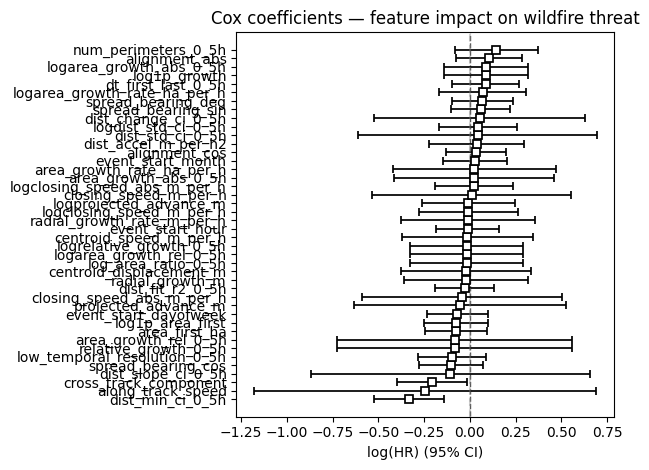

In [21]:
# Plot coefficients with 95% confidence intervals
# Positive values increase the hazard (hit sooner); negative values decrease it (survives longer).
best_model.plot()
plt.title('Cox PH Coefficients — Feature Impact on Wildfire Threat')
plt.axvline(0, linestyle='--', alpha=0.4, color='gray')
plt.tight_layout()
plt.show()


The coefficient plot provides a consolidated view of all feature effects. Most coefficients cluster near zero, consistent with their statistical non-significance. A subset of features shows larger magnitude estimates, suggesting they carry more predictive information.

**Proportional Hazards Assumption Check**

The Cox model requires that each covariate's hazard ratio remains constant over time (i.e., the log-hazard difference between any two covariate levels is time-invariant). This is tested via Schoenfeld residuals. A statistically significant test for a covariate indicates a violation of the assumption. In this case, the assumption holds for all features.

Checking proportional hazards assumption...

   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May ta

/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/lifelines/fitters/mixins.py:123: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = plt.figure()



   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lin

[[<Axes: xlabel='rank-transformed time\n(p=0.2256)'>,
  <Axes: xlabel='km-transformed time\n(p=0.2822)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.3914)'>,
  <Axes: xlabel='km-transformed time\n(p=0.4491)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.3888)'>,
  <Axes: xlabel='km-transformed time\n(p=0.4380)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.8280)'>,
  <Axes: xlabel='km-transformed time\n(p=0.8312)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.8734)'>,
  <Axes: xlabel='km-transformed time\n(p=0.8847)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.7855)'>,
  <Axes: xlabel='km-transformed time\n(p=0.8047)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.8198)'>,
  <Axes: xlabel='km-transformed time\n(p=0.8376)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.1925)'>,
  <Axes: xlabel='km-transformed time\n(p=0.1961)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.6806)'>,
  <Axes: xlabel='km-transformed time\n(p=0.7059)'>],
 [<Axes: xlabel='rank-transformed tim

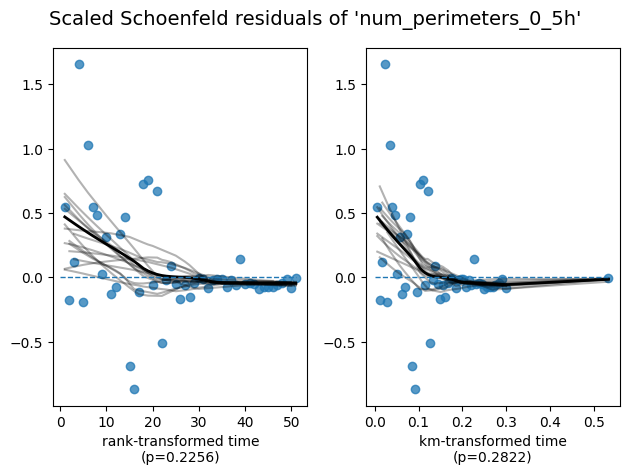

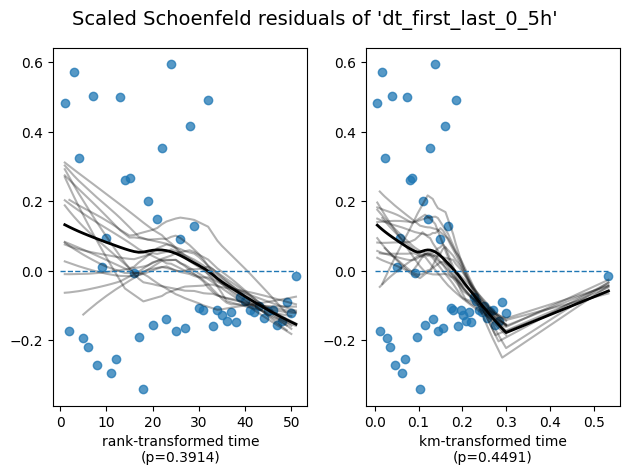

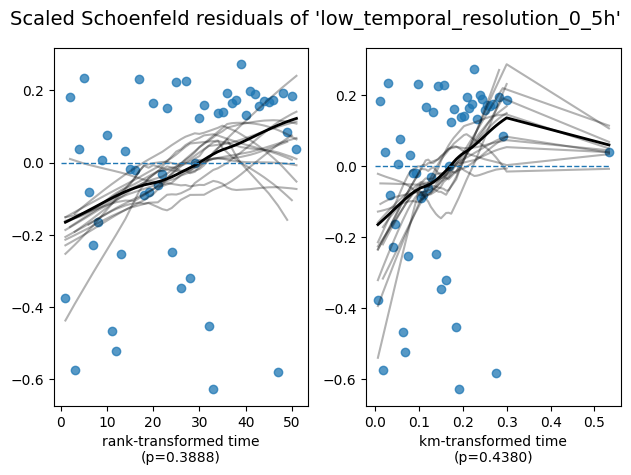

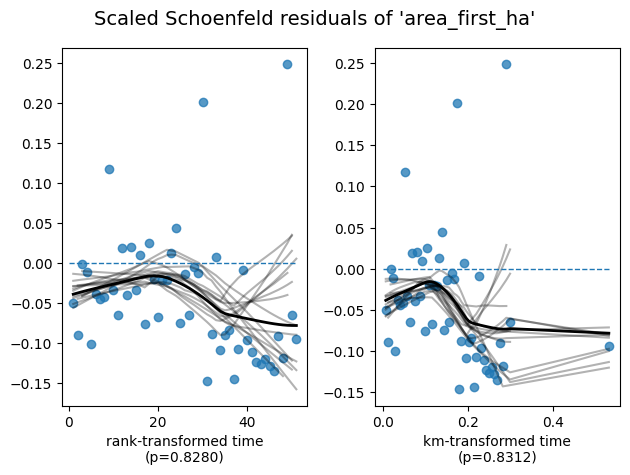

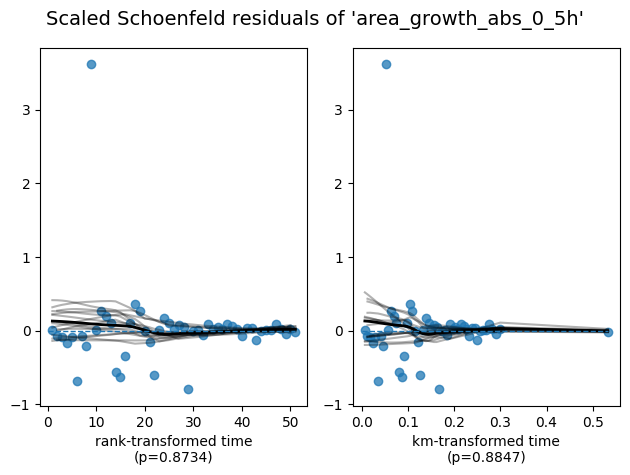

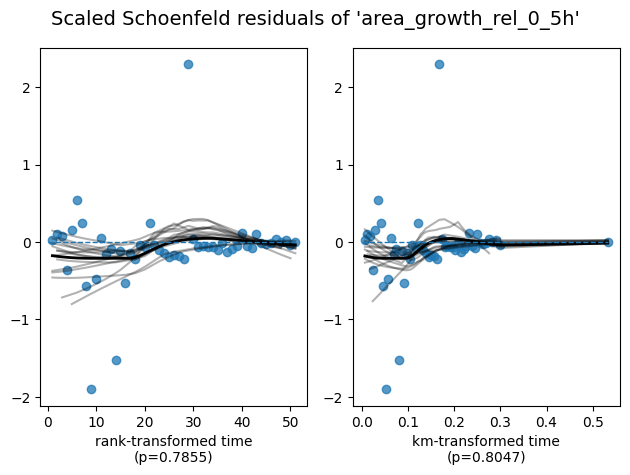

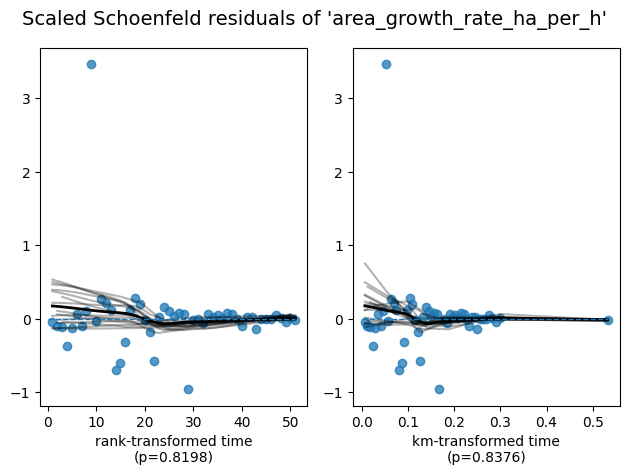

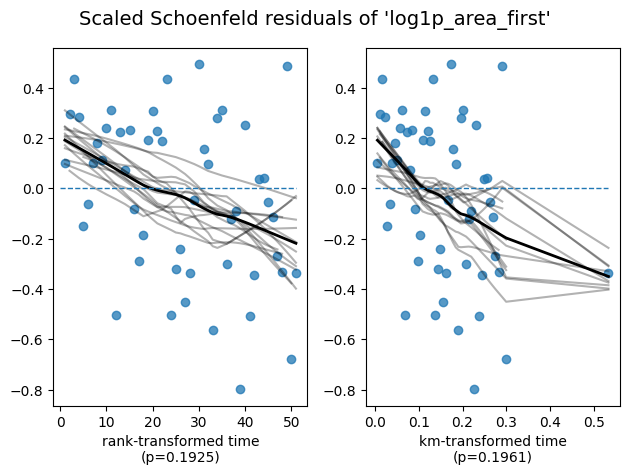

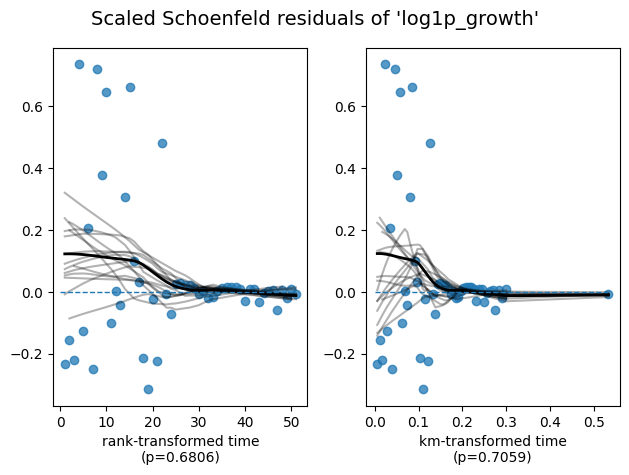

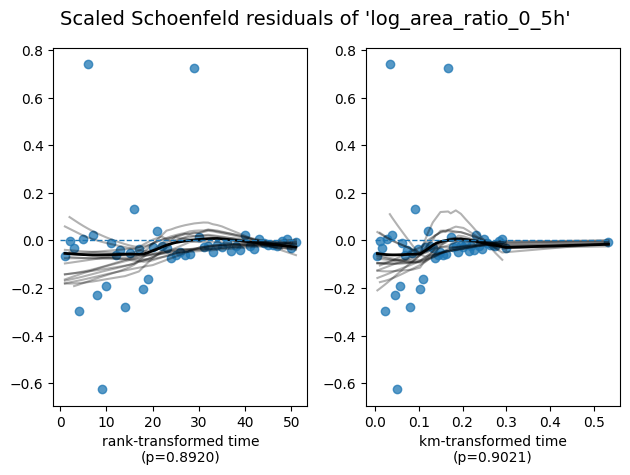

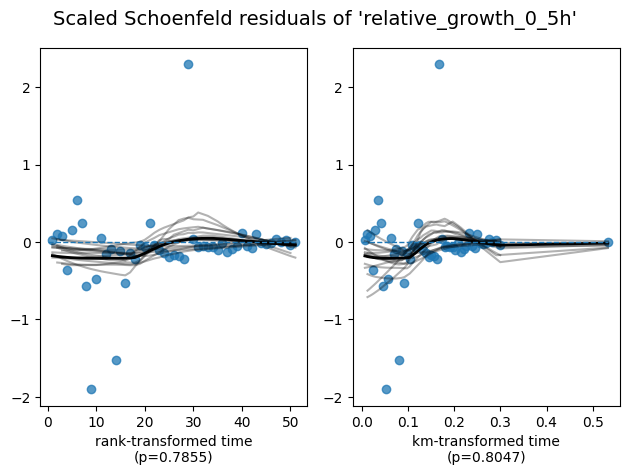

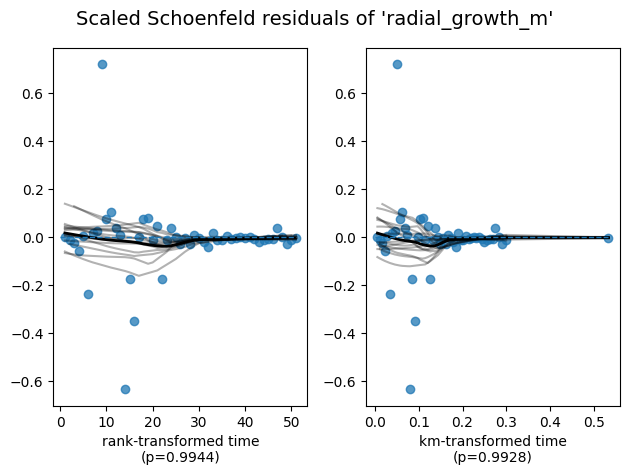

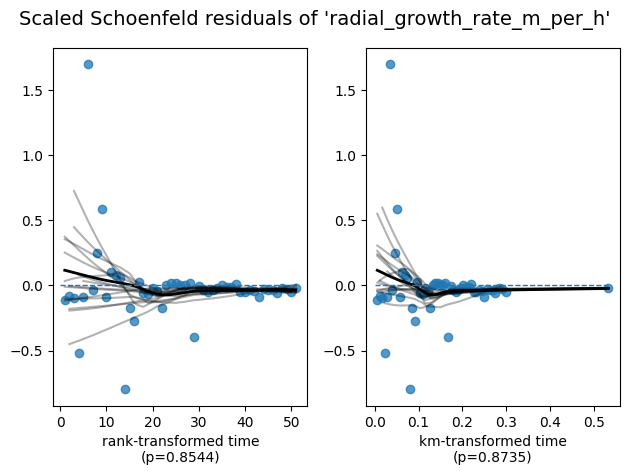

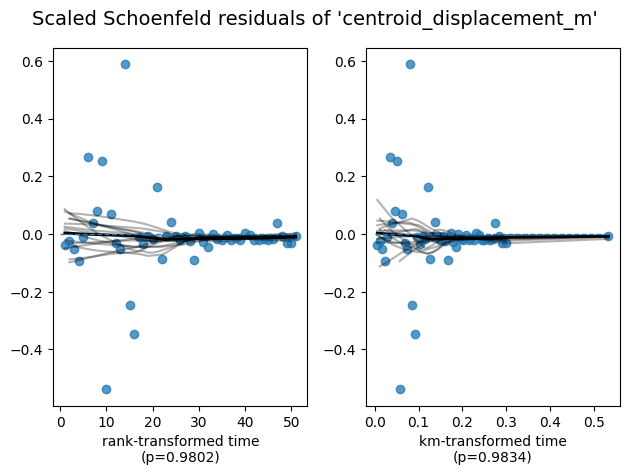

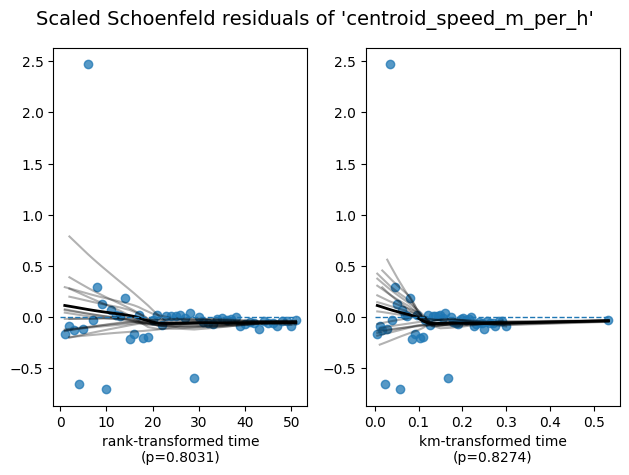

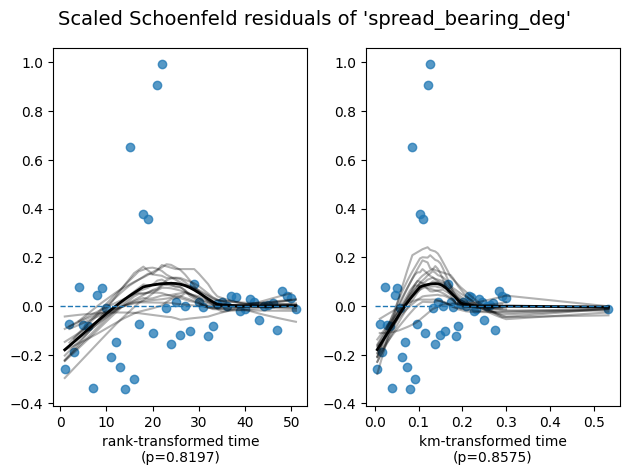

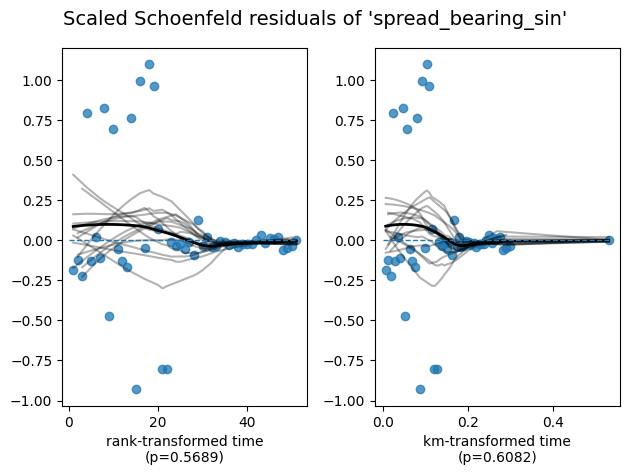

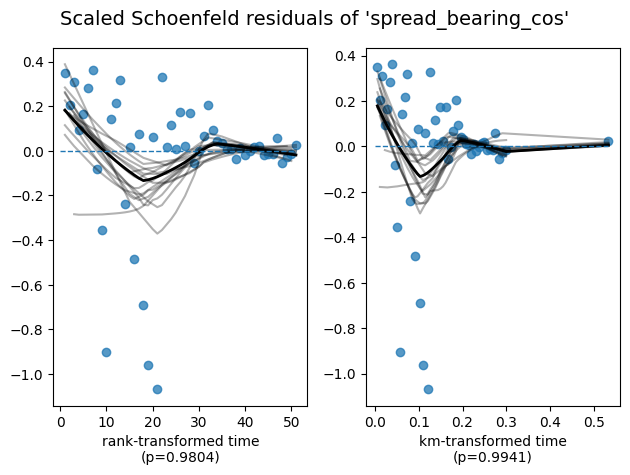

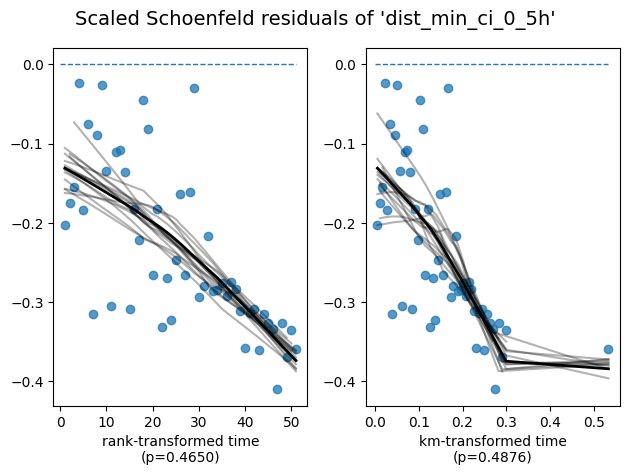

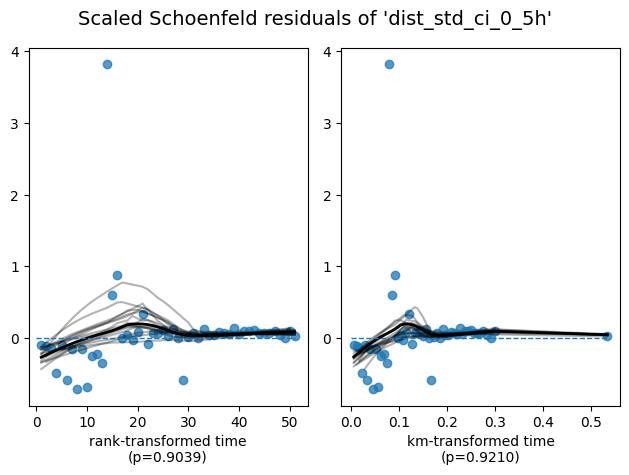

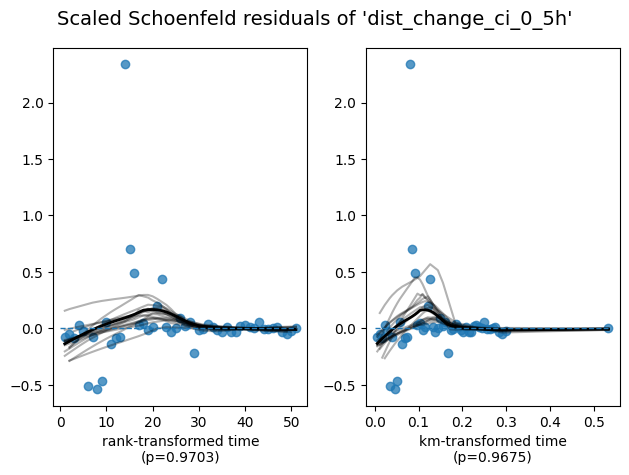

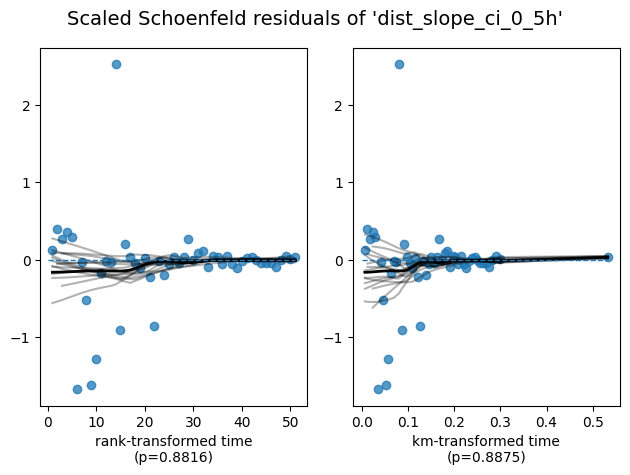

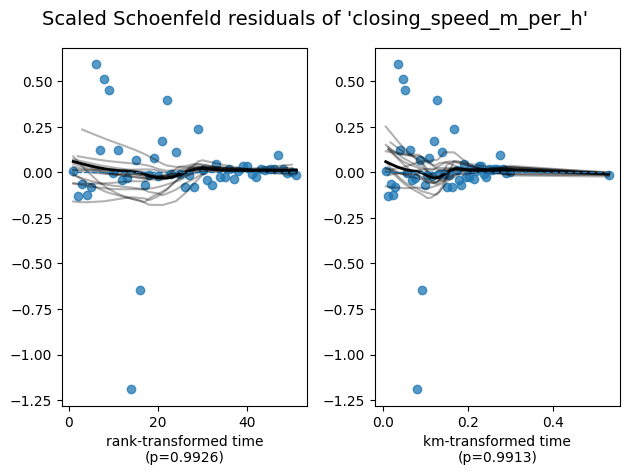

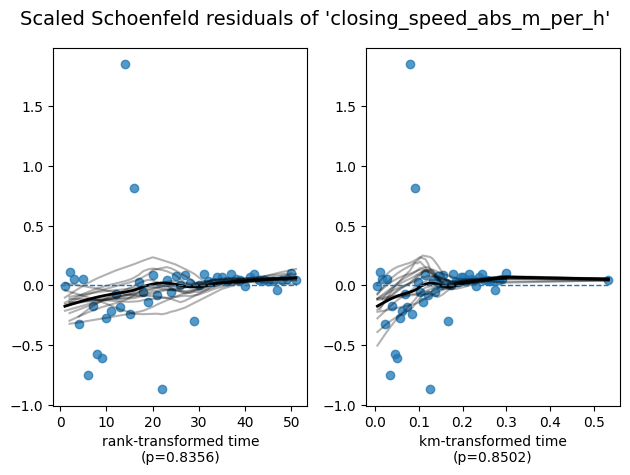

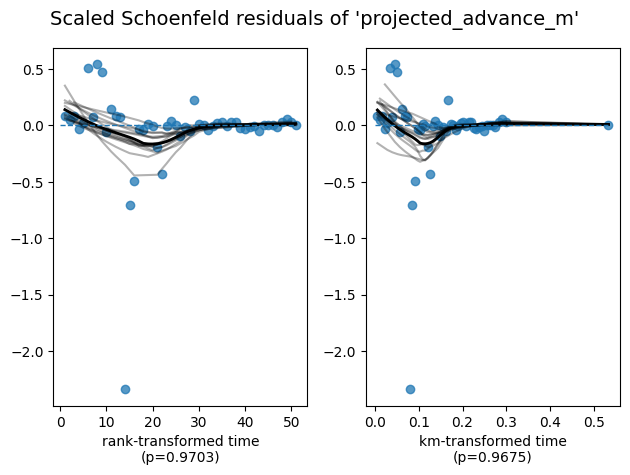

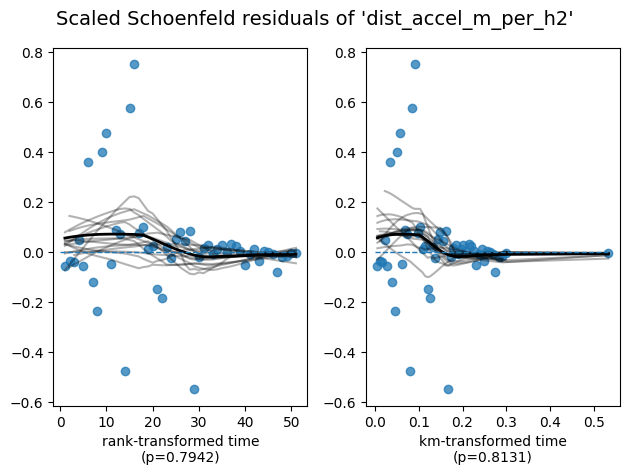

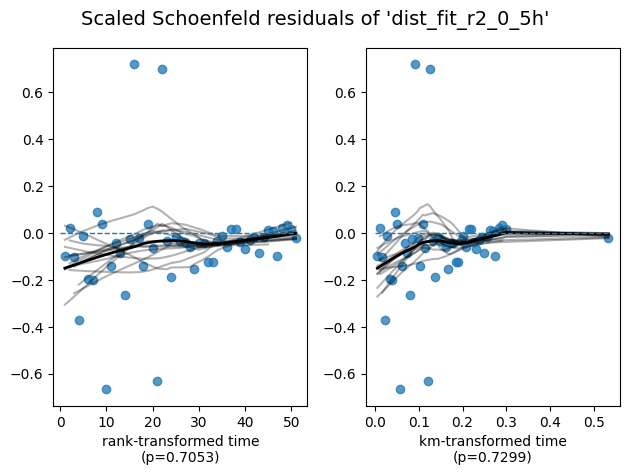

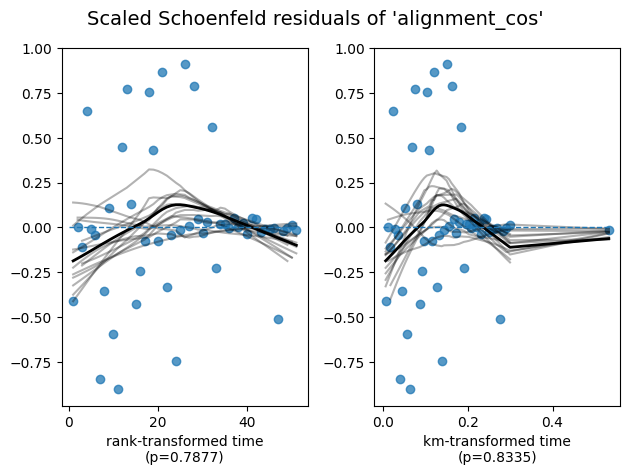

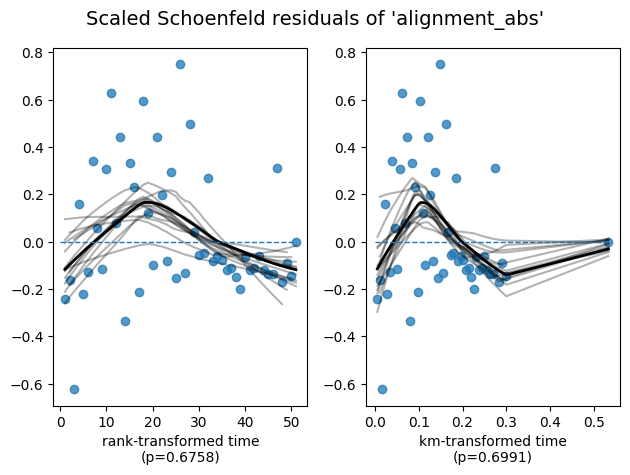

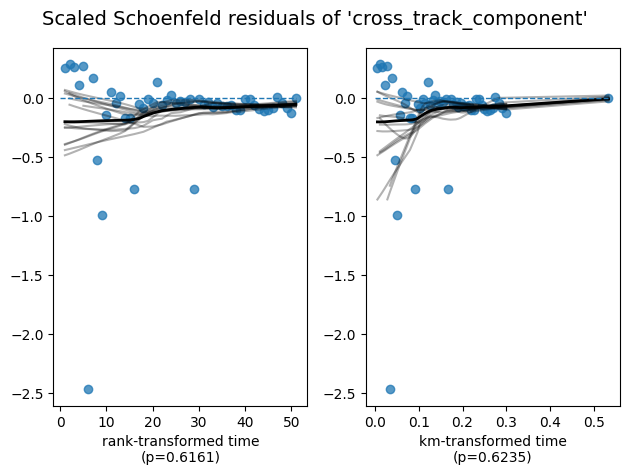

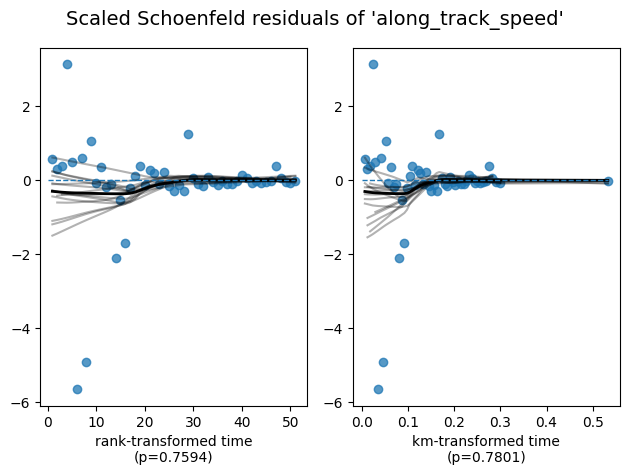

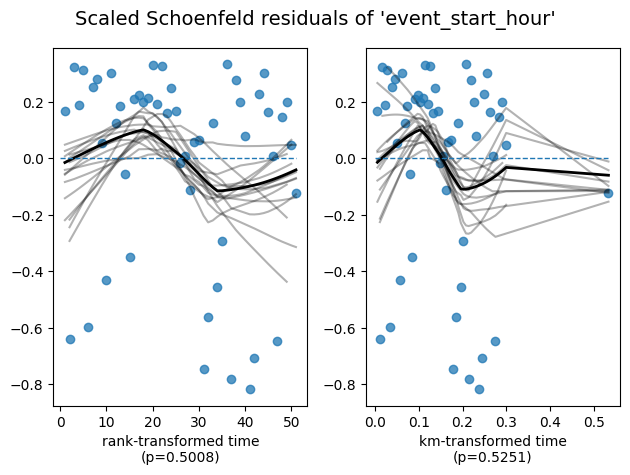

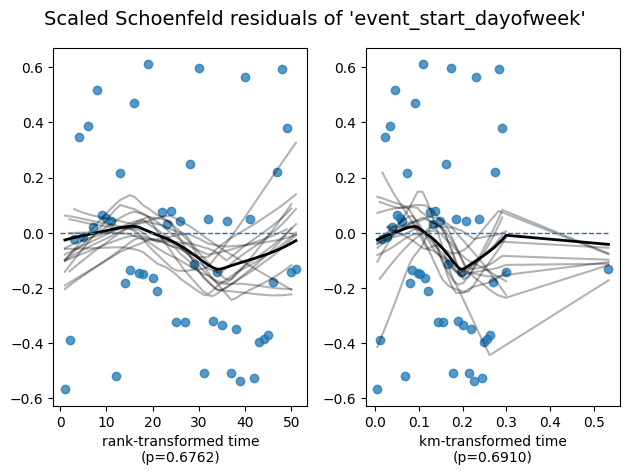

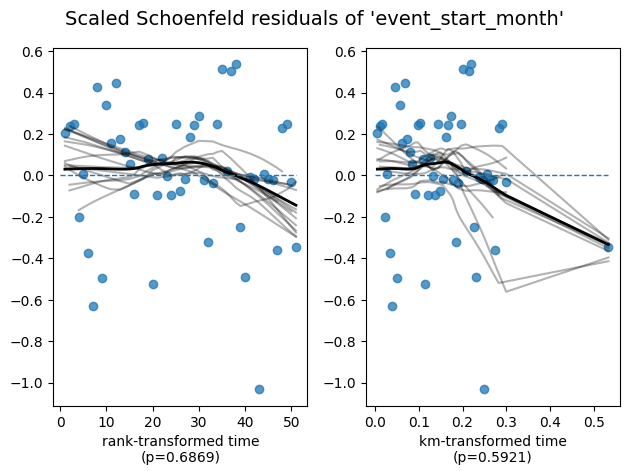

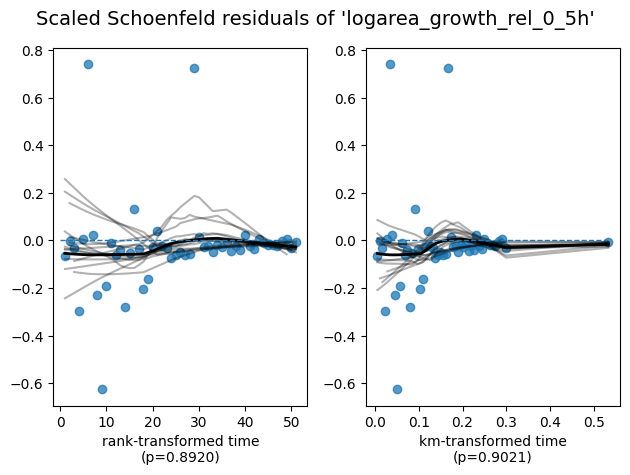

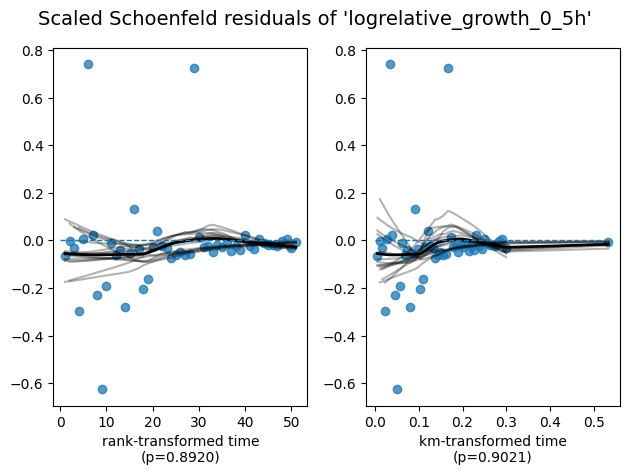

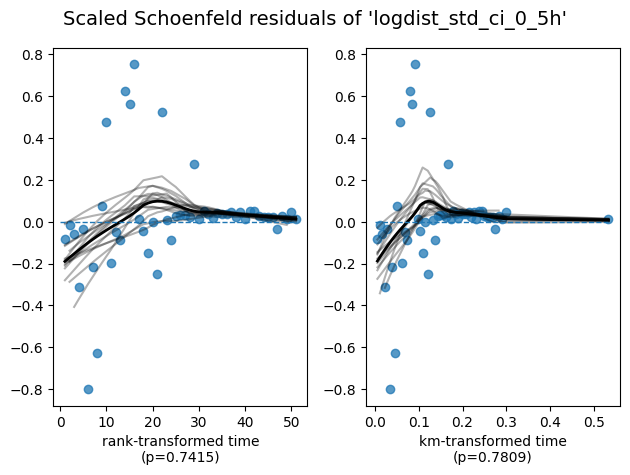

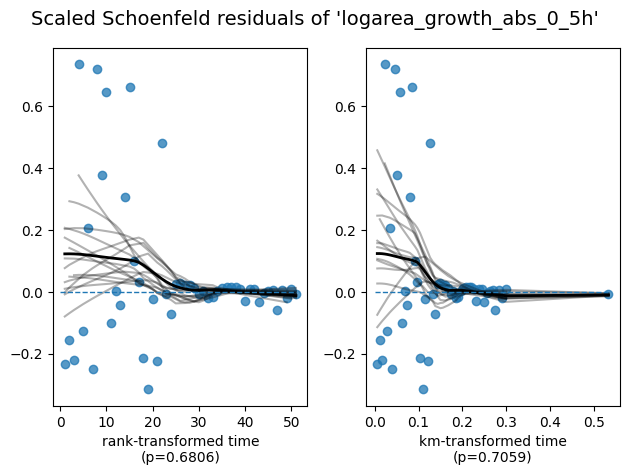

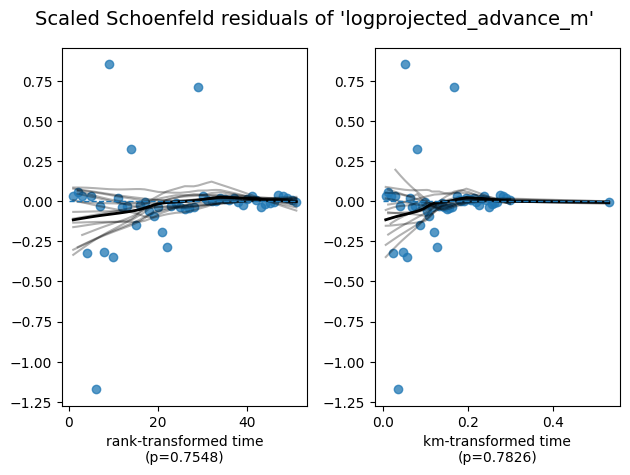

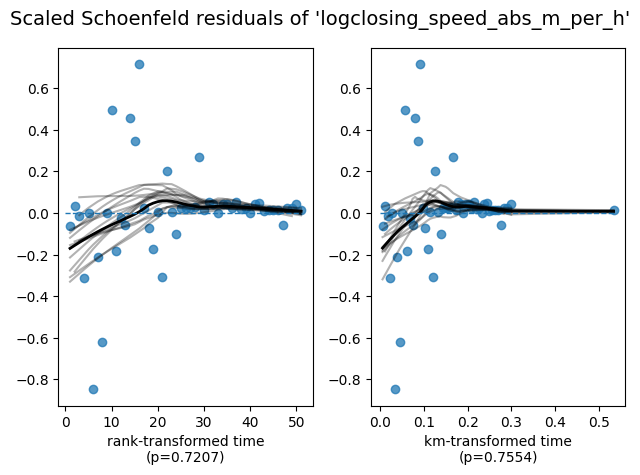

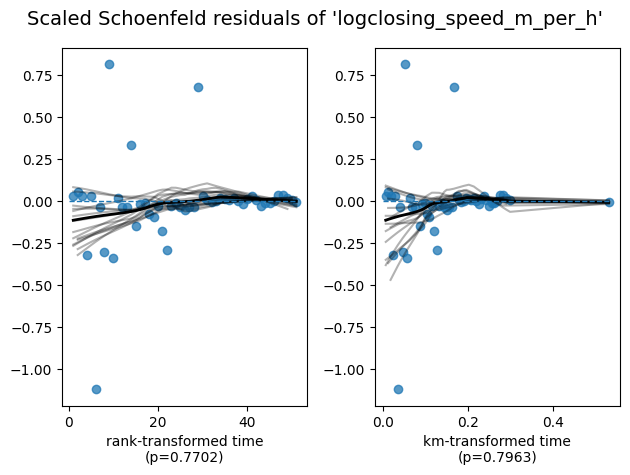

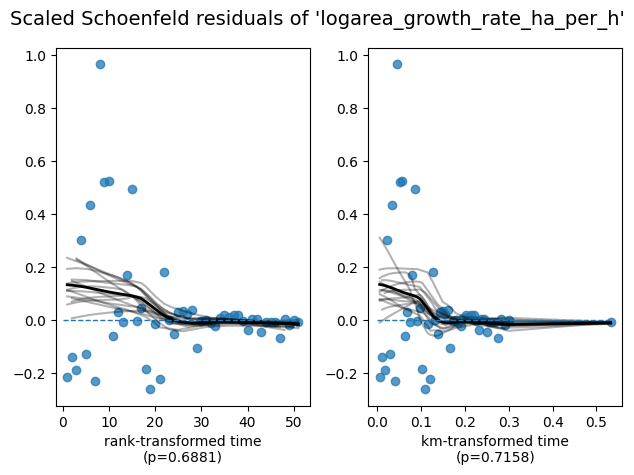

In [22]:
# Verify the proportional hazards assumption using Schoenfeld residuals
print("Checking proportional hazards assumption...")
best_model.check_assumptions(
    cox_train,
    p_value_threshold=0.05,
    show_plots=False
)


Final validation C-index: 0.8742

Interpretation:
  0.5 = random (coin flip)
  0.6 = weak signal
  0.7 = decent predictive power
  0.8 = strong
  0.9+ = excellent


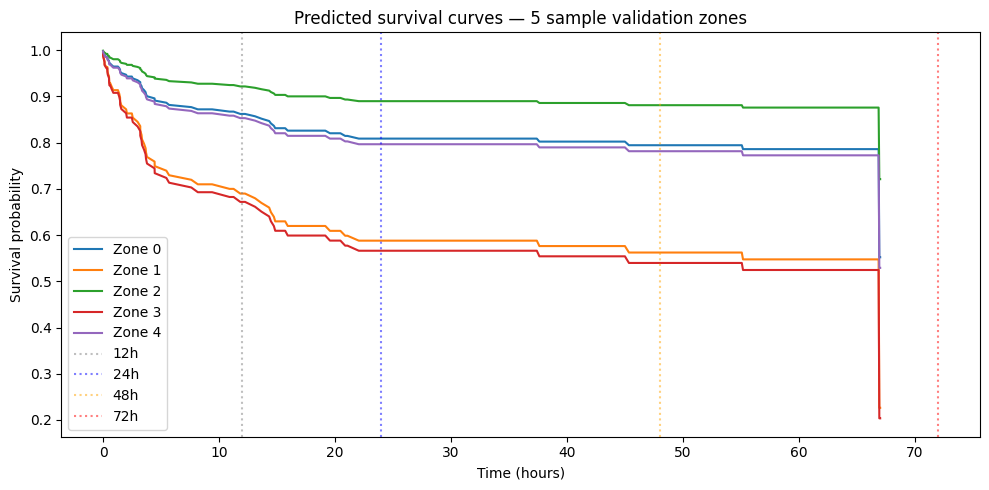

In [ ]:
# EVALUATE ON VALIDATION SET

val_risk = best_model.predict_partial_hazard(cox_val)
c_final  = concordance_index(time_val, -val_risk, event_val)

print(f"Final validation C-index: {c_final:.4f}")
print()
print("Interpretation:")
print("  0.5 = random (no discrimination)")
print("  0.6 = weak signal")
print("  0.7 = moderate predictive power")
print("  0.8 = strong")
print("  0.9+ = excellent")


In [ ]:
# GENERATE SUBMISSION

# Predict the full survival function for each test zone
# Returns a DataFrame: rows = unique event times, columns = test observations
sf_test = best_model.predict_survival_function(cox_test)

print("Available time points in survival function:")
print(sf_test.index.tolist())


def prob_at_time(sf_df, target_time):
    """
    Extract survival probability at the nearest available time point.

    Parameters
    ----------
    sf_df : pd.DataFrame
        Survival function DataFrame (rows = time points, columns = observations).
    target_time : float
        Desired time horizon in hours.

    Returns
    -------
    np.ndarray
        Survival probabilities for all test observations at the nearest time point.
    """
    nearest_time = sf_df.index[np.argmin(np.abs(sf_df.index - target_time))]
    print(f"  Requested t={target_time}h → using t={nearest_time}h")
    return sf_df.loc[nearest_time].values


print("\nExtracting probabilities at required time horizons:")
p12 = prob_at_time(sf_test, 12)
p24 = prob_at_time(sf_test, 24)
p48 = prob_at_time(sf_test, 48)
p72 = prob_at_time(sf_test, 72)

# Build submission DataFrame
submission = pd.DataFrame({
    'event_id': test['event_id'],
    'prob_12h': p12,
    'prob_24h': p24,
    'prob_48h': p48,
    'prob_72h': p72,
})

# Sanity checks
print("\nSubmission preview:")
print(submission.head(10))
print(f"\nShape:     {submission.shape}")
print(f"Any nulls: {submission.isnull().any().any()}")
print("\nProbability ranges:")
for col in ['prob_12h', 'prob_24h', 'prob_48h', 'prob_72h']:
    print(f"  {col}: {submission[col].min():.3f} – {submission[col].max():.3f}")

# Survival probabilities must be monotonically non-increasing over time
assert (submission['prob_12h'] >= submission['prob_24h']).all(), "prob_12h should be >= prob_24h"
assert (submission['prob_24h'] >= submission['prob_48h']).all(), "prob_24h should be >= prob_48h"
assert (submission['prob_48h'] >= submission['prob_72h']).all(), "prob_48h should be >= prob_72h"

print("\nAll sanity checks passed!")

submission.to_csv('submission_cox.csv', index=False)
print("Saved to submission_cox.csv")


Time points in survival function:
[0.0012202119444444, 0.0071762169444444, 0.0643609547222222, 0.1303196202777778, 0.1329790244444444, 0.2922721472222222, 0.3744860833333333, 0.3765659569444444, 0.4100321630555555, 0.5149067594444444, 0.5237634105555555, 0.547744816111111, 0.6173444741666666, 0.7434419508333334, 0.8888954830555557, 1.2861299941666668, 1.3979693241666669, 1.4691954252777777, 1.4752310216666666, 1.5778597725, 1.9929637366666664, 2.059227285833334, 2.483279283888889, 2.5644396191666665, 2.980008299722222, 3.209417225277778, 3.211343435, 3.3202997266666667, 3.3625956216666664, 3.534845605, 3.6673862175, 3.7071967341666654, 3.791231432222222, 4.443049115555556, 4.457485441111111, 5.458663006666667, 5.694898473888888, 7.611519684166666, 8.173316426666666, 9.404261130833332, 10.90745898861111, 11.25434434111111, 11.829236373333334, 12.242322164444444, 13.107416989166666, 13.65678695611111, 14.323375001111112, 14.473698290277778, 14.728139878333334, 14.845391848611111, 14.9815